## First Steps: Import all libreries required

In [28]:
import fastf1 as f1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Pandas version: ',pd.__version__)
print('Numpy version: ',np.__version__)
print('Seaborn version: ',sns.__version__)
print('Fastf1 version: ',f1.__version__)


Pandas version:  2.3.3
Numpy version:  2.4.3
Seaborn version:  0.13.2
Fastf1 version:  3.8.1


## Declaration of the development environment

In [29]:
import sys, random, platform

RANDOM_SEED = 414

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Platform:', platform.platform())
print(f'Python  : {sys.version.split()[0]}')

Platform: Linux-6.19.7-1-cachyos-x86_64-with-glibc2.42
Python  : 3.13.11


## Import relevant data

In [30]:
years, results = [2022,2023,2024], []

for i in years:
    
    schedule = f1.get_event_schedule(i)
    
    for race in schedule['EventName']:
        
        try:
            session = f1.get_session(i, race, 'R')
            session.load(laps=False, telemetry=False, weather=False)
            res = session.results
            res['year'], res['race'] = i, race
            results.append(res)
        
        except:
            pass

df = pd.concat(results, ignore_index=True)

events      WARNING 	Correcting user input 'Pre-Season Track Session' to 'British Grand Prix'
core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '11', '44', '16', '14', '4', '1', '47', '5', '20', '18', '6', '3', '22', '31', '10', '77', '63', '24', '23']
events      WARNING 	Correcting user input 'Pre-Season Test' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '16', '11', '63', '4', '14', '5', '20', '22', '31', '24', '23', '

## A brief look at the data

In [52]:
display(df.head(3))

columns = [x for x in df.columns]
print('DataFrame Shape: ',df.shape)
print('DataFrame Columns: ', columns)

missing = df.isna().sum().reset_index()
missing.columns = ['Column', 'MissingValues']
display(missing)

dtypes_df = pd.DataFrame({
    'Column': df.columns,
    'DataType': df.dtypes.values
})

display(dtypes_df)

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Q1,Q2,Q3,Time,Status,Points,Laps,year,race,top_10
0,55,C SAINZ,SAI,sainz,Ferrari,ed1c24,ferrari,Carlos,Sainz,Carlos Sainz,...,NaT,NaT,NaT,0 days 02:17:50.311000,Finished,25.0,52.0,2022,Pre-Season Track Session,True
1,11,S PEREZ,PER,perez,Red Bull Racing,1e5bc6,red_bull,Sergio,Perez,Sergio Perez,...,NaT,NaT,NaT,0 days 00:00:03.779000,Finished,18.0,52.0,2022,Pre-Season Track Session,True
2,44,L HAMILTON,HAM,hamilton,Mercedes,6cd3bf,mercedes,Lewis,Hamilton,Lewis Hamilton,...,NaT,NaT,NaT,0 days 00:00:06.225000,Finished,16.0,52.0,2022,Pre-Season Track Session,True


DataFrame Shape:  (1439, 25)
DataFrame Columns:  ['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName', 'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName', 'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition', 'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps', 'year', 'race', 'top_10']


,Column,MissingValues
0,DriverNumber,0
1,BroadcastName,0
2,Abbreviation,0
3,DriverId,0
4,TeamName,0
5,TeamColor,0
6,TeamId,0
7,FirstName,0
8,LastName,0
9,FullName,0


,Column,DataType
0,DriverNumber,object
1,BroadcastName,object
2,Abbreviation,object
3,DriverId,object
4,TeamName,object
5,TeamColor,object
6,TeamId,object
7,FirstName,object
8,LastName,object
9,FullName,object


### Question 1: Is the dataset balanced between Top-10 and non-Top-10 finishes?

/tmp/ipykernel_2067/1279926073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='top_10', data=df, palette=['#A10000', '#00AD18'])


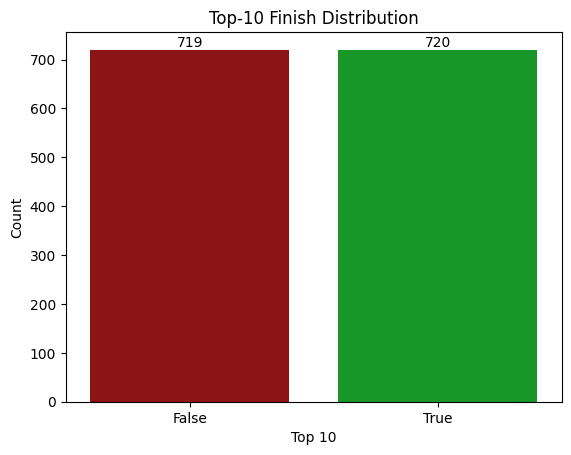

In [32]:
# PLOT 1: Top-10 Finish Distribution

df['top_10'] = df['Position'] <= 10

ax = sns.countplot(x='top_10', data=df, palette=['#A10000', '#00AD18'])

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top-10 Finish Distribution")
plt.xlabel("Top 10")
plt.ylabel("Count")

plt.show()

### Interpretation:

Arround 50% of drivers finish in the Top-10, and 50% finish outside oof this group. This is expected because each race has around 20 drivers and exactly 10 Top-10 positions.

### Decision:

Given that the set of drivers finishing in the top 10 is balanced, a benchmark model that consistently predicts a class would achieve an accuracy of around 50%. Therefore, any predictive model must significantly exceed this threshold to provide useful predictions, as half of the data meets the condition.



### Question 2: Does starting grid position influence the probability of finishing in the Top-10?

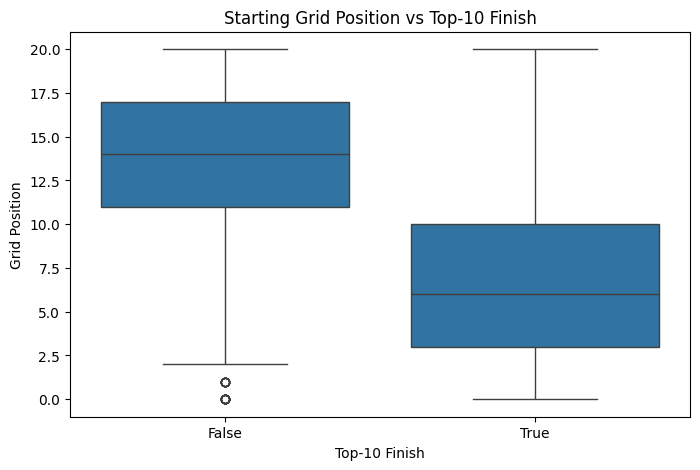

In [ ]:
#PLOT 2: Starting Grid Position vs Top-10 Finish

# Aclaration: Grid is the initial position of the driver at the start of the race, so a lower grid position means a better starting position, while a higher grid position means a worse starting position.
    
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="top_10",
    y="GridPosition"
)

plt.title("Starting Grid Position vs Top-10 Finish")
plt.xlabel("Top-10 Finish")
plt.ylabel("Grid Position")

plt.show()

### Interpretation:

Drivers starting closer to the front of the grid tend to finish in the Top-10 more frequently.

### Decision:

The position on the grid appears to be a good predictor and should be taken into account for the reference heuristic.

### Question 3: Do some teams achieve Top-10 finishes more frequently than others?

/tmp/ipykernel_2067/3512236208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


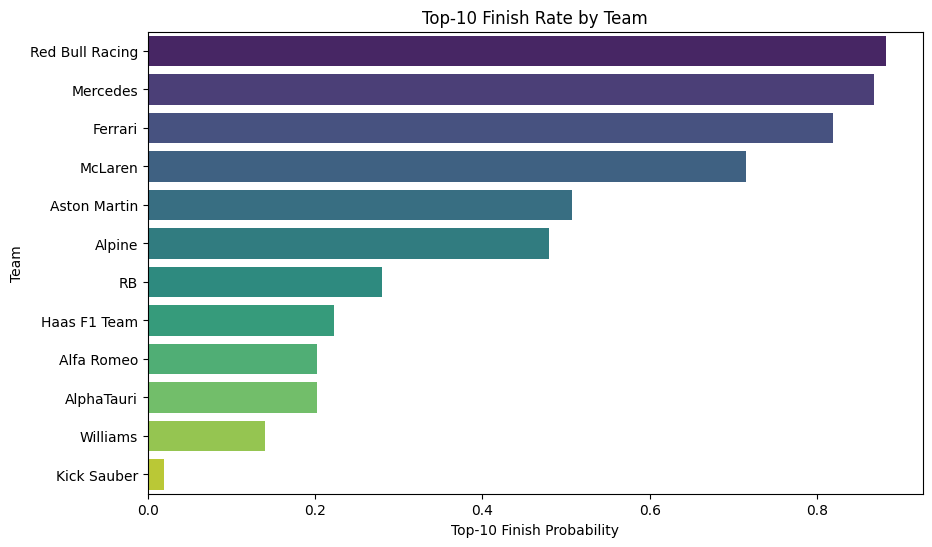

In [ ]:
team_top10 = df.groupby("TeamName")["top_10"].mean().sort_values(ascending=False)
team_top10 = team_top10.reset_index()

plt.figure(figsize=(10,6))

sns.barplot(data=team_top10, x="top_10", y="TeamName", palette="viridis")

plt.title("Top-10 Finish Rate by Team")
plt.xlabel("Top-10 Finish Probability")
plt.ylabel("Team")

plt.show()

### Interpretation:

There are 3 teams that achive Top 10 finishies significantly more than other, namely:

    1. Red Bull
    2. McLaren
    3. Ferrari

This suggests that team performance is a very important factor influencing race outcomes.

### Decision:

Team appears to be an important feature influencing Top-10 outcome, so it will be considered as a strong potential predictor in future modeling steps.

### Question 3: Do Top-10 finish patterns remain consistent across seasons?

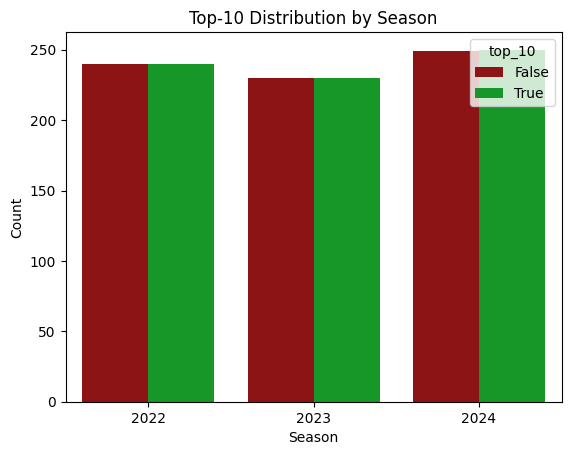

In [58]:
year_top10 = df.groupby("year")["top_10"].mean().reset_index()

sns.countplot(
    data=df,
    x="year",
    hue="top_10",
    palette=['#A10000', '#00AD18']
)

plt.title("Top-10 Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Count")

plt.show()

### Interpretation:

The proportion of Top 10 results appears to be consistent across seasons. The visualization shows that the distribution of top ten results remains relatively stable across the seasons included in the dataset.

### Decision:

The stability of the top 10 finisher distribution across seasons suggests that the target variable remains constant over time.

**However**, it's not a good idea to train a model using only this column to predict the top 10. While a proportion remains consistent over the years, this graph doesn't include all the teams that finished in the top 10. Therefore, while it can be used for training, it should be used with recent years, as team performance can change over time (temporal leakage).



### Question 5: Which numeric features are most correlated with race finishing position?

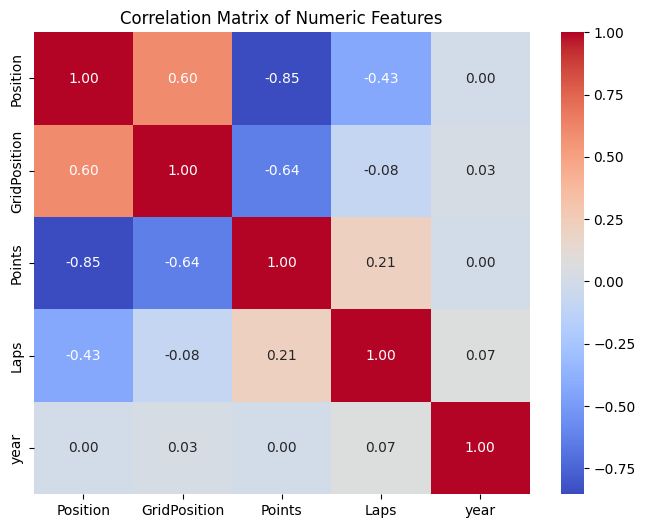

In [61]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

numeric_df = df[numeric_cols]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numeric Features")

plt.show()

### Interpretation:

The correlation analysis shows that grid position has a strong positive relationship with finishing position, meaning that drivers who start further back tend to finish in worse positions.
Furthermore, points are also correlated with finishing position.

### Decision:

Regarding numerical values, only grid position will be taken into account, as points are awarded at the end of the race based on driver performance, so introducing them into the predictive model would be a serious error **(DATA LEAKAGE)**.



## Temporal Train / Validation / Test split

- Train: 2022–2023, viewing previous years could alter the model's predictions for the reasons explained above.
- Validation: early 2024, it should be validated with recent data, but not the most recent data available.
- Test: late 2024, current data

## 1-3-1 Summary

